<a href="https://colab.research.google.com/github/mamadou-thiaw/Apprentissage/blob/main/Devoir_Mamadou_Thiaw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mamadou Thiaw
# Matricule : XXXXXXXXXX

# Reponse question 2.1) Visualisation , nettoyage et pipeline des données

In [ ]:
#Chargement des données: train et test
import pandas as pd # importation du module pandas
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
train = pd.read_csv("/content/drive/My Drive/train.csv")
test = pd.read_csv("/content/drive/My Drive/test.csv")

Mounted at /content/drive


In [ ]:
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [ ]:
train.shape

(7352, 563)

In [ ]:
train.info(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Data columns (total 563 columns):
 #    Column                                Dtype  
---   ------                                -----  
 0    tBodyAcc-mean()-X                     float64
 1    tBodyAcc-mean()-Y                     float64
 2    tBodyAcc-mean()-Z                     float64
 3    tBodyAcc-std()-X                      float64
 4    tBodyAcc-std()-Y                      float64
 5    tBodyAcc-std()-Z                      float64
 6    tBodyAcc-mad()-X                      float64
 7    tBodyAcc-mad()-Y                      float64
 8    tBodyAcc-mad()-Z                      float64
 9    tBodyAcc-max()-X                      float64
 10   tBodyAcc-max()-Y                      float64
 11   tBodyAcc-max()-Z                      float64
 12   tBodyAcc-min()-X                      float64
 13   tBodyAcc-min()-Y                      float64
 14   tBodyAcc-min()-Z                      float64
 15   tB

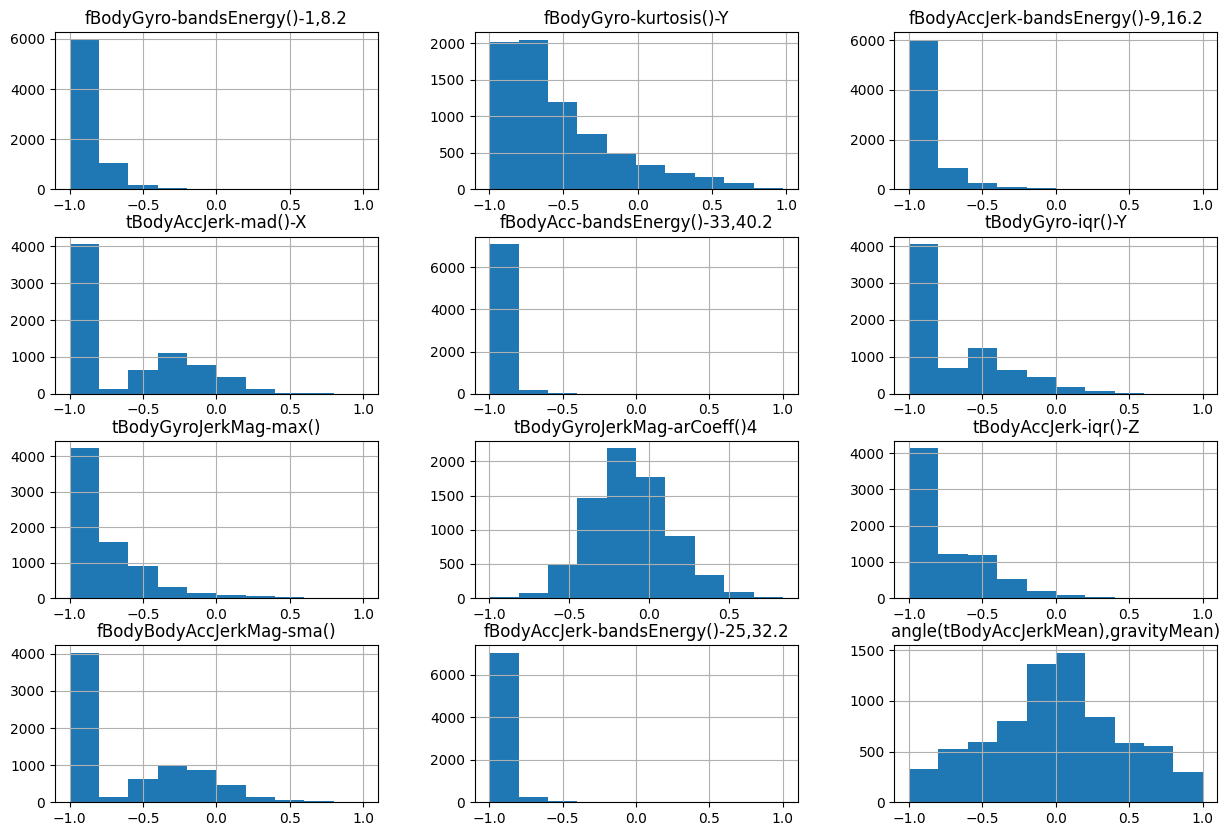

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Sélectionner aléatoirement 10 colonnes numériques
subset = train.select_dtypes(include=['number']).sample(n=12, axis=1, random_state=42)

# Tracer les histogrammes
subset.hist(bins=10, figsize=(15, 10))
plt.show()


In [ ]:
print(train["subject"].unique())  # Affiche les valeurs distinctes de la variable subject


[ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]


In [ ]:
print(train["subject"].value_counts())  # Affiche le nombre d'occurrences de chaque valeur


subject
25    409
21    408
26    392
30    383
28    382
27    376
23    372
17    368
16    366
19    360
1     347
29    344
3     341
15    328
6     325
14    323
22    321
11    316
7     308
5     302
8     281
Name: count, dtype: int64


**la variable subject n'est pas indispensable car elle n'a pas d'effet sur l'accuracy.De plus pour que le modèle soit généralisable à toute personne, il ne doit pas dépendre de subject**

In [ ]:
# la variable subject n'est pas indispensable car elle n'a pas d'effet sur l'accuracy.De plus pour que le modèle soit généralisable à toute personne, il ne doit pas dépendre de subject
train_set =  train.drop("subject", axis=1)

**Séparation de la variable cible Activity avec la variable explicative Activity**

In [ ]:
train_data = train_set.drop("Activity", axis=1)
train_labels = train_set["Activity"].copy()

In [ ]:
#Visualisation des variables explicatives sans la variable subject
train_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [ ]:
#Affichage des classes de la variable Activity
train_labels.value_counts()

,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


**Utilisation de simpleImputer pour éviter les valeurs manquantes**

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [ ]:
imputer.fit(train_data)

SimpleImputer(strategy='median')

In [ ]:
#Application de Imputer sur toutes la variables numériques pour eviter des valeurs manquantes
imputer.statistics_

array([ 2.77193355e-01, -1.72191435e-02, -1.08676250e-01, -9.46196395e-01,
       -8.51896640e-01, -8.59364595e-01, -9.50709140e-01, -8.57328375e-01,
       -8.57142890e-01, -8.81637305e-01, -4.79677410e-01, -7.36515570e-01,
        7.92060065e-01,  6.27736525e-01,  7.78059410e-01, -8.85460945e-01,
       -9.98046230e-01, -9.94065030e-01, -9.85545630e-01, -9.57859360e-01,
       -8.96093265e-01, -8.64515050e-01, -7.33689755e-02, -1.36792775e-01,
       -1.48888680e-01, -1.29392570e-01,  7.00729385e-02, -1.90008810e-02,
        1.34148595e-01, -4.07103875e-02,  1.17479770e-02,  1.68444095e-01,
       -2.24475890e-02,  2.90437590e-02,  3.26577075e-03,  4.94318595e-02,
       -8.19403680e-02, -1.63727750e-01, -1.89672690e-01,  1.47481965e-01,
        9.19512530e-01, -1.43563995e-01,  2.64101460e-02, -9.81907970e-01,
       -9.76307260e-01, -9.66165855e-01, -9.82637585e-01, -9.77259360e-01,
       -9.67313545e-01,  8.57334850e-01, -1.51599465e-01,  3.68113230e-02,
        9.26692630e-01, -

**Encodage de la variable cible Activity avec l'encodeur LabelEncoder**

In [ ]:
#Voyons d'abord les différentes classes de la colonnes Activity
train_labels.value_counts()

,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


In [ ]:
train_labels.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7352 entries, 0 to 7351
Series name: Activity
Non-Null Count  Dtype 
--------------  ----- 
7352 non-null   object
dtypes: object(1)
memory usage: 57.6+ KB


**Encodage des classes de la cible Activity:** WALKING : 0, STANDING :1,
LAYING:2, WALKING_UPSTAIRS :3, SITTING :4, WALKING_DOWNSTAIRS :5

In [ ]:
#Encodage des classes
from sklearn.preprocessing import LabelEncoder

# Liste des classes
classes = ['WALKING', 'STANDING', 'LAYING', 'WALKING_UPSTAIRS', 'SITTING', 'WALKING_DOWNSTAIRS']

# Création du LabelEncoder
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(classes)

# Encodage des labels
train_labels_encoded = label_encoder.transform(train_labels)

# Nombre d'occurences pour chaque label encodée correspondant
train_labels_encoded_series = pd.Series(train_labels_encoded)
print(train_labels_encoded_series.value_counts())
#ici on peut voir que


2    1407
1    1374
4    1286
0    1226
3    1073
5     986
Name: count, dtype: int64


In [ ]:
train_labels_encoded_series.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7352 entries, 0 to 7351
Series name: None
Non-Null Count  Dtype
--------------  -----
7352 non-null   int64
dtypes: int64(1)
memory usage: 57.6 KB


**Création du pipeline pour les variables explication**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

my_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler())
    ])


train_data_preparee = my_pipeline.fit_transform(train_data)


In [ ]:
train_data_preparee

array([[ 0.20064157, -0.0636826 , -0.41962845, ..., -0.68721921,
         0.40794614, -0.00756789],
       [ 0.05594788,  0.03148567, -0.25390836, ..., -0.694138  ,
         0.40911698,  0.00787517],
       [ 0.07351535, -0.04341648, -0.07629468, ..., -0.702239  ,
         0.4102883 ,  0.02650234],
       ...,
       [-0.01566765,  0.0167814 ,  1.13222107, ..., -0.56584847,
         0.64059683,  0.34870928],
       [ 0.21586648, -0.02812252, -0.86770988, ..., -0.57766781,
         0.63147758,  0.29327564],
       [ 1.09620157,  0.12919873, -1.67268082, ..., -0.57392691,
         0.63274259,  0.33396081]])

# Réponse question 2.2) Entraînement des modèle(DecisionTreeClassifier(DT), RandomForest(RF), XGBoost) par la validation croisée pour k = 3

**2.2.1) Entrainement du modèle DecisionTreeClassifier(DT) par la validation croisée pour k=3**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialisation du modèle d'arbre de décision
tree_clf = DecisionTreeClassifier(max_depth=10, random_state=42)

# Entraînement sur les données préparées
tree_clf.fit(train_data_preparee, train_labels_encoded)


DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
# Prédictions en validation croisée
dt_cv_predictions = cross_val_predict(tree_clf, train_data_preparee, train_labels_encoded, cv=3)
print(dt_cv_predictions)

[4 1 1 ... 5 5 5]


**2.2.2) Entrainement du modèle RandomForest (RF) par la validation croisée pour k=3**

In [ ]:
#Entraînement du modèle RandomForest(RF)
from sklearn.ensemble import RandomForestClassifier

# Initialisation du modèle
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraînement du modèle
forest_clf.fit(train_data_preparee, train_labels_encoded)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_predict
# Calcul des predictions avec la validation croisée
rf_cv_predictions = cross_val_predict(forest_clf, train_data_preparee, train_labels_encoded, cv=3)
print(rf_cv_predictions)

[1 1 1 ... 3 3 3]


**2.2.3) Entrainement du modèle XGBOOST par la validation croisée pour k=3**

In [ ]:
from xgboost import XGBClassifier

# Initialisation du modèle XGBoost
xgb_clf = XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.2, random_state=42)

# Entraînement du modèle
xgb_clf.fit(train_data_preparee, train_labels_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
from sklearn.model_selection import cross_val_predict

# Prédictions en validation croisée
cv_xgb_predictions = cross_val_predict(xgb_clf, train_data_preparee, train_labels_encoded, cv=3)
print(cv_xgb_predictions)

[1 1 1 ... 3 3 3]


# Réponse question 2.3) Mesure des métriques précisions, rapel et f-score de chacun des modèles

**2.3-1) Mesure des métriques de précision, rappel et f-score du modèle DecisionTreeClassifier par la validation croisée K=3**

Après la validation croisée, l'accuracy du modèle DecisionTreeClassifier est de 83%

In [ ]:
from sklearn.metrics import classification_report

#La vriable dt_cv_predictions contient les prédictions obtenues par validation croisée du modèle DecisionTreeClassifier sur train_data_preparee

print(classification_report(train_labels_encoded, dt_cv_predictions))


              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1226
           1       0.83      0.84      0.83      1374
           2       0.99      1.00      0.99      1407
           3       0.76      0.64      0.69      1073
           4       0.82      0.82      0.82      1286
           5       0.73      0.81      0.76       986

    accuracy                           0.83      7352
   macro avg       0.82      0.82      0.82      7352
weighted avg       0.83      0.83      0.83      7352



**2.3-2) Mesure des métriques de précision, rappel et f-score du modèle RandomForest par la validation croisée k=3**

Après la validation croisée, l'accuracy du modèle RandomForest est de 91%

In [ ]:
from sklearn.metrics import classification_report

#La vriable rf_cv_predictions contient les prédictions obtenues par validation croisée du modèle RandomForest sur train_data_preparee
print(classification_report(train_labels_encoded, rf_cv_predictions))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91      1226
           1       0.88      0.90      0.89      1374
           2       0.99      1.00      0.99      1407
           3       0.82      0.92      0.87      1073
           4       0.89      0.88      0.89      1286
           5       0.91      0.87      0.89       986

    accuracy                           0.91      7352
   macro avg       0.91      0.91      0.91      7352
weighted avg       0.91      0.91      0.91      7352



**2.3-3) Mesure des métriques de précision, rappel et f-score du modèle XGBOOST par la validation croisée k=3**

Après la validation croisée, l'accuracy du modèle XGBoost est de 90%

In [ ]:
from sklearn.metrics import classification_report

#La vriable cv_xgb_predictions contient les prédictions obtenues par validation croisée du modèle XGBoost sur train_data_preparee
print(classification_report(train_labels_encoded, cv_xgb_predictions))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1226
           1       0.89      0.89      0.89      1374
           2       0.98      1.00      0.99      1407
           3       0.85      0.87      0.86      1073
           4       0.88      0.86      0.87      1286
           5       0.89      0.89      0.89       986

    accuracy                           0.90      7352
   macro avg       0.90      0.90      0.90      7352
weighted avg       0.90      0.90      0.90      7352



# Réponse question 2.4) Optimisation des hyperparametres par la méthodes GridSearchCV et RandomizedSearchCV

**2.4.1) GridSearchCV avec le modèle DecisionTreeClassifier**

In [ ]:
# Réglage du modele DecisionTreeClassifier : recherche GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Définition de la grille des hyperparamètres
param_grid = {
    "max_depth": [5, 10, 15, None],  # Tester différentes profondeurs
    "min_samples_split": [2, 5, 10],  # Nombre min d’échantillons pour diviser un nœud
    "min_samples_leaf": [1, 2, 4],  # Nombre min d’échantillons dans une feuille
}

# Initialisation du modèle DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(random_state=42)

# Initialisation de GridSearchCV
grid_search = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid,
    cv=3,  # Validation croisée à 3 folds
    scoring="accuracy",  # Évaluation avec l'accuracy
)

# Lancer la recherche des meilleurs hyperparamètres
grid_search.fit(train_data_preparee, train_labels_encoded)



GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleure précision obtenue :", grid_search.best_score_)
best_dt_tree_clf = grid_search.best_estimator_
print("Meilleure précision obtenue :", best_dt_tree_clf)

Meilleurs hyperparamètres : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Meilleure précision obtenue : 0.8328326908078614
Meilleure précision obtenue : DecisionTreeClassifier(max_depth=10, random_state=42)


**2.4.2) RandomizedSearchCV avec le modèle RandomForest**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Définition de la distribution des hyperparamètres
param_dist = {
    "n_estimators": np.arange(50, 300, 50),  # Entre 50 et 300, par pas de 50
    "max_depth": [10, 20, 30, None],  # Profondeur maximale
    "min_samples_split": [2, 5, 10],  # Nombre min d'échantillons pour diviser un nœud
    "min_samples_leaf": [1, 2, 4],  # Nombre min d'échantillons dans une feuille
}

# Initialisation du modèle
forest_clf = RandomForestClassifier(random_state=42)

# Initialisation de RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=forest_clf,
    param_distributions=param_dist,
    n_iter=10,  # Nombre d'itérations (combinaisons aléatoires)
    cv=3,  # Validation croisée à 3 folds
    scoring="accuracy",  # Évaluation avec l'accuarcy
    random_state=42
)

# Lancer la recherche des meilleurs hyperparamètres
random_search.fit(train_data_preparee, train_labels_encoded)



RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': array([ 50, 100, 150, 200, 250])},
                   random_state=42, scoring='accuracy')

In [ ]:
print("Meilleurs hyperparamètres :", random_search.best_params_)
print("Meilleure précision obtenue :", random_search.best_score_)
best_randomforest_clf = random_search.best_estimator_
print("Meilleure modèle obtenu:", best_randomforest_clf)

Meilleurs hyperparamètres : {'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
Meilleure précision obtenue : 0.9145824139529332
Meilleure modèle obtenu: RandomForestClassifier(max_depth=10, min_samples_leaf=2, n_estimators=250,
                       random_state=42)


**2.4.3) RandomizedSearchCV avec le modèle XGBOOST**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Définition de la distribution des hyperparamètres
param_dist = {
    "n_estimators": np.arange(100, 500, 50),  # Entre 100 et 500, avec un pas de 50
    "max_depth": [3, 6, 10, 15],  # Profondeur de l'arbre
    "learning_rate": np.linspace(0.01, 0.3, 5),  # Taux d'apprentissage entre 0.01 et 0.3
    "subsample": [0.6, 0.8, 1.0],  # Fraction des échantillons utilisés
    "colsample_bytree": [0.6, 0.8, 1.0],  # Fraction des features utilisées par arbre
    "gamma": [0, 0.1, 0.2, 0.3]  # Régularisation
}

# Initialisation du modèle XGBoost
xgb_clf = XGBClassifier(eval_metric="mlogloss", random_state=42)

# Initialisation de RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=15,  # Nombre de combinaisons aléatoires testées
    cv=3,  # Validation croisée à 3 folds
    scoring="accuracy",  # Évaluation avec l'accuracy
    random_state=42
)

# Lancer la recherche des meilleurs hyperparamètres
random_search_xgb.fit(train_data_preparee, train_labels_encoded)


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learnin...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=15,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': array([0.01  , 0.0825, 0.155 , 0.2275, 0.3   ]),
                                        'max_depth': [3, 6, 10, 15],
                                        'n_estimators': array([100, 150, 200, 250, 300, 350, 400, 450]),
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='accuracy')

In [ ]:
print("Meilleurs hyperparamètres :", random_search_xgb.best_params_)
print("Meilleure précision obtenue :", random_search_xgb.best_score_)

best_xgboost_clf = random_search_xgb.best_estimator_
print("Meilleure modèle obtenu:", best_xgboost_clf)

Meilleurs hyperparamètres : {'subsample': 0.6, 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.22749999999999998, 'gamma': 0.2, 'colsample_bytree': 0.8}
Meilleure précision obtenue : 0.9211133592563913
Meilleure modèle obtenu: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.22749999999999998, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ob

# Réponse 2.5) Test des meilleurs models obtenu après la recherche(GridSearchCV et RandomizedSearchCV) sur le jeu de test

Evaluation des meilleurs modèles sur le jeu de test

In [ ]:
#Evaluation des modèles sur le jeu de test

X_test = test.drop("Activity", axis=1)
X_test_sub = X_test.drop("subject", axis=1)
y_test_labels = test["Activity"].copy()


#encodage des classes du jeu de test
from sklearn.preprocessing import LabelEncoder

# Liste des classes
classes = ['WALKING', 'STANDING', 'LAYING', 'WALKING_UPSTAIRS', 'SITTING', 'WALKING_DOWNSTAIRS']

# Création du LabelEncoder
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(classes)

# Encodage des labels
test_labels_encoded = label_encoder.transform(y_test_labels)

**2.5.1) Test du meilleur modèle DecisionTreeClassifier sur le jeu de test**

Le test du meilleur modèle de DecisionTreeClassifier sur les données de test atteint une accuracy de 86.19%

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

#Appel du my_pipeline sur les données de test
X_test_preparee = my_pipeline.transform(X_test_sub)
final_predictions = best_dt_tree_clf.predict(X_test_preparee) #best_tree_clf est le meilleur modèle obtenu en utilisant l'hypermaratère GridSearchCV
accuracy = accuracy_score(test_labels_encoded, final_predictions)

print(f"Accuracy sur les données de test du meilleur modèle DecisionTreeClassifier : {accuracy:.4f}")
# Affichage des metriques précision, rappel et f1-score
print("Rapport de classification :\n", classification_report(test_labels_encoded, final_predictions))


Accuracy sur les données de test du meilleur modèle DecisionTreeClassifier : 0.8619
Rapport de classification :
               precision    recall  f1-score   support

           0       0.83      0.91      0.87       496
           1       0.80      0.88      0.84       532
           2       1.00      1.00      1.00       537
           3       0.83      0.77      0.80       471
           4       0.86      0.75      0.80       491
           5       0.85      0.84      0.84       420

    accuracy                           0.86      2947
   macro avg       0.86      0.86      0.86      2947
weighted avg       0.86      0.86      0.86      2947



**2.5.2) Test du meilleur modèle RandomForest(RF) sur le jeu de test**

Le test du meilleur modèle de RandomForest sur les données de test atteint une accuracy de 92.67%

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

#Appel my_pipeline sur les données de test
X_test_preparee = my_pipeline.transform(X_test_sub)
final_predictions = best_randomforest_clf.predict(X_test_preparee) #best_randomforest_clf est le meilleur modèle obtenu en utilisant l'hypermaratère RandomizedSearchCV
accuracy = accuracy_score(test_labels_encoded, final_predictions)

#Affichage de l'accuracy
print(f"Accuracy sur les données de test du meilleur modèle RandomForest : {accuracy:.4f}")

# Affichage des metriques précision, rappel et f1-score
print("Rapport de classification :\n", classification_report(test_labels_encoded, final_predictions))

Accuracy sur les données de test du meilleur modèle RandomForest : 0.9267
Rapport de classification :
               precision    recall  f1-score   support

           0       0.90      0.97      0.93       496
           1       0.89      0.93      0.91       532
           2       1.00      1.00      1.00       537
           3       0.90      0.92      0.91       471
           4       0.92      0.87      0.90       491
           5       0.96      0.84      0.90       420

    accuracy                           0.93      2947
   macro avg       0.93      0.92      0.92      2947
weighted avg       0.93      0.93      0.93      2947



**2.5.3) Test du meilleur modèle XGBOOST sur le jeu de test**

Le test du meilleur modèle de XGBoost sur les données de test atteint une accuracy de 95.18%

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

#Appel my_pipeline sur les données de test
X_test_preparee = my_pipeline.transform(X_test_sub)
final_predictions = best_xgboost_clf.predict(X_test_preparee) #best_xgboost_clf est le meilleur modèle obtenu en utilisant l'hypermaratère RandomizedSearchCV
accuracy = accuracy_score(test_labels_encoded, final_predictions)

#Affichage de l'accuracy
print(f"Accuracy sur les données de test du meilleur modèle XGBOOST : {accuracy:.4f}")

# Affichage des metriques précision, rappel et f1-score
print("Rapport de classification :\n", classification_report(test_labels_encoded, final_predictions))

Accuracy sur les données de test du meilleur modèle XGBOOST : 0.9518
Rapport de classification :
               precision    recall  f1-score   support

           0       0.94      0.99      0.96       496
           1       0.91      0.96      0.94       532
           2       1.00      1.00      1.00       537
           3       0.93      0.93      0.93       471
           4       0.95      0.90      0.92       491
           5       0.98      0.93      0.95       420

    accuracy                           0.95      2947
   macro avg       0.95      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947



# Réponse question 2.6) Représentration graphiquement et à l’aide de tableaux l’ensemble des résultats des métriques de performance

Pour répondre à cette question, je regroupe tous les métriques de performances des trois modèles dans un seul tableau ensuite tracer le diagramme de barre des trois modèles

In [ ]:
from sklearn.metrics import classification_report

# Liste des classes
classes = ['WALKING', 'STANDING', 'LAYING', 'WALKING_UPSTAIRS', 'SITTING', 'WALKING_DOWNSTAIRS']

# Récupérations des rapports de classification sous forme de dictionnaire
report_dt = classification_report(test_labels_encoded, best_dt_tree_clf.predict(X_test_preparee), target_names=classes, output_dict=True)
report_rf = classification_report(test_labels_encoded, best_randomforest_clf.predict(X_test_preparee), target_names=classes, output_dict=True)
report_xgb = classification_report(test_labels_encoded, best_xgboost_clf.predict(X_test_preparee), target_names=classes, output_dict=True)

# Création d'un DataFrame pour chaque modèle
df_dt = pd.DataFrame(report_dt).transpose()
df_rf = pd.DataFrame(report_rf).transpose()
df_xgb = pd.DataFrame(report_xgb).transpose()

# Ajout d'une colonne pour le modèle
df_dt["Modèle"] = "DecisionTree"
df_rf["Modèle"] = "RandomForest"
df_xgb["Modèle"] = "XGBoost"

# Concaténer les DataFrames
df_results = pd.concat([df_dt, df_rf, df_xgb])

# On garde uniquement les classes (ignorer "accuracy", "macro avg", "weighted avg".)
df_results = df_results.loc[classes]

# Réinitialiser l'index pour affichage
df_results.reset_index(inplace=True)
df_results.rename(columns={"index": "Classe"}, inplace=True)

# Affichage du tableau final
print(df_results)


                Classe  precision    recall  f1-score  support        Modèle
0              WALKING   0.832103  0.909274  0.868979    496.0  DecisionTree
1              WALKING   0.902256  0.967742  0.933852    496.0  RandomForest
2              WALKING   0.938815  0.989919  0.963690    496.0       XGBoost
3             STANDING   0.795262  0.883459  0.837044    532.0  DecisionTree
4             STANDING   0.887500  0.934211  0.910256    532.0  RandomForest
5             STANDING   0.913978  0.958647  0.935780    532.0       XGBoost
6               LAYING   1.000000  1.000000  1.000000    537.0  DecisionTree
7               LAYING   1.000000  1.000000  1.000000    537.0  RandomForest
8               LAYING   1.000000  1.000000  1.000000    537.0       XGBoost
9     WALKING_UPSTAIRS   0.833718  0.766454  0.798673    471.0  DecisionTree
10    WALKING_UPSTAIRS   0.895062  0.923567  0.909091    471.0  RandomForest
11    WALKING_UPSTAIRS   0.929787  0.927813  0.928799    471.0       XGBoost

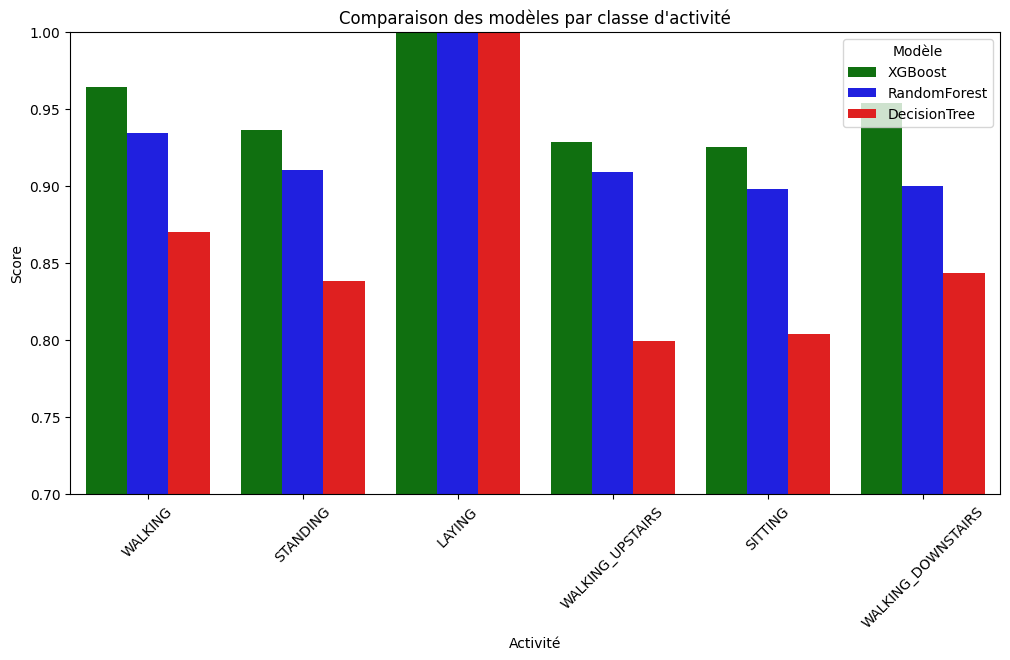

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Définition des couleurs pour chaque modèle
palette_custom = {
    "XGBoost": "green",
    "RandomForest": "blue",
    "DecisionTree": "red"
}

# Transformation des données pour seaborn
df_melted = df_results.melt(id_vars=["Classe", "Modèle"], value_vars=["precision", "recall", "f1-score"],
                            var_name="Métrique", value_name="Score")

# Création du graphique avec les couleurs définies
plt.figure(figsize=(12, 6))
sns.barplot(x="Classe", y="Score", hue="Modèle", data=df_melted, palette=palette_custom, hue_order=["XGBoost", "RandomForest", "DecisionTree"], errorbar=None)

# Ajout des labels
plt.title("Comparaison des modèles par classe d'activité")
plt.xlabel("Activité")
plt.ylabel("Score")
plt.xticks(rotation=45)  # Inclinaison des labels
plt.ylim(0.7, 1)
plt.legend(title="Modèle")

# Affichage du graphique
plt.show()


# Réponse question 2.7) Analyse et interprétation les résultats obtenus
**2.7.1) Analyse des resultats**

D'après les résultats, pour la classe LAYING, le score F1 est de 100% pour tous les modèles (DecisionTreeClassifier, RandomForest et XGBoost), ce qui indique que cette activité est parfaitement identifiée.

En revanche, pour les classes WALKING, STANDING et WALKING_UPSTAIRS, XGBoost obtient les meilleures performances, suivi de RandomForest.

Concernant les classes SITTING et WALKING_DOWNSTAIRS, XGBoost reste en tête avec les meilleures performances, suivi de RandomForest. Cependant, on observe une diminution du rappel pour tous les modèles sur ces deux classes, ce qui signifie que certains exemples de ces catégories sont mal classifiés.

**2.7.2) Interprétation**

D'après l'analyse des résultats, XGBoost est le modèle le plus performant, affichant des scores F1 élevés sur toutes les classes et atteignant une accuracy de 95.18%.

RandomForest, bien que plus rapide que XGBoost, est légèrement moins performant, avec une accuracy de 92.67%. Il reste cependant nettement supérieur à DecisionTreeClassifier.

Enfin, DecisionTreeClassifier est le moins performant, atteignant une accuracy de 86.19%. Ses scores F1 sont plus faibles, en particulier sur les classes WALKING_UPSTAIRS et SITTING.

# Réponse question 2.8) Comparaison des quatres modèles SVM, DT, RF et XGBoost

**Comparaison:**

Pour la classe LAYING, tous les modèles (SVM, Decision Tree, Random Forest et XGBoost) identifient correctement cette classe, atteignant une précision et un rappel de 100 %.

En revanche, pour les autres classes (WALKING, STANDING, WALKING_UPSTAIRS, SITTING et WALKING_DOWNSTAIRS), le modèle SVM est plus performant que Random Forest et Decision Tree en termes de précision et de rappel. Il surpasse également XGBoost, mais légèrement.

Cela montre que XGBoost reste un modèle puissant, capable de rivaliser avec SVM.

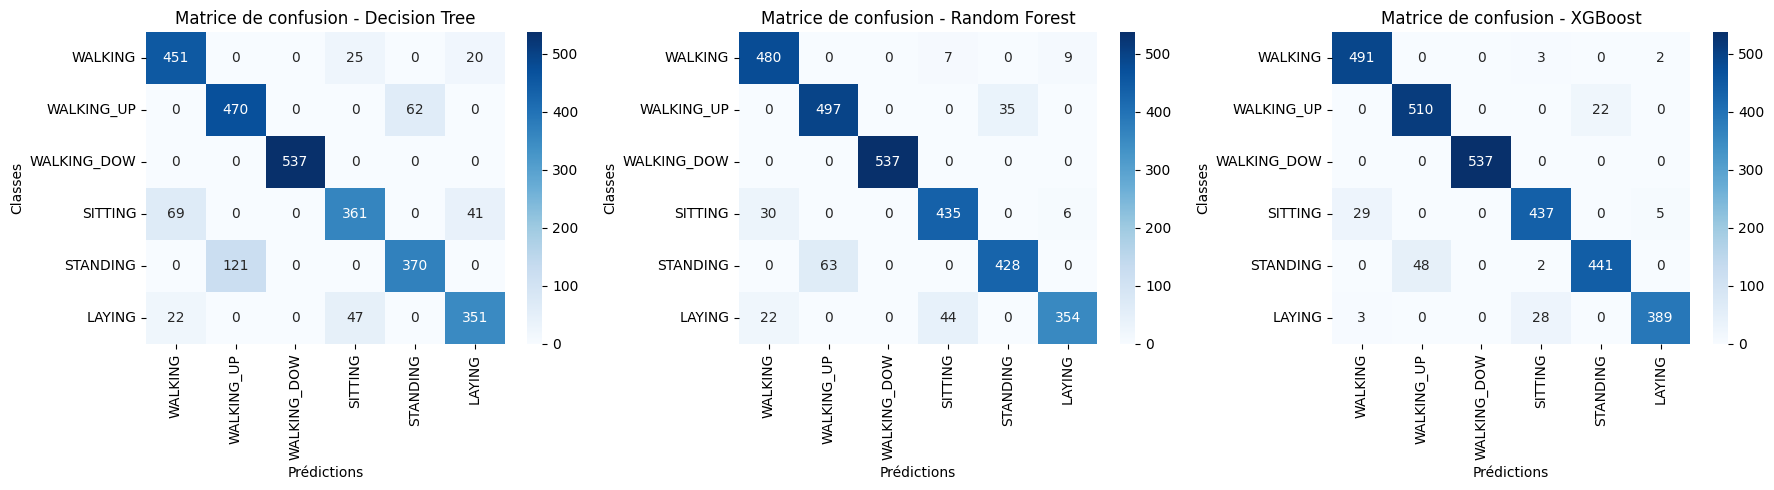

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Liste des modèles et noms pour affichage
models = {
    "Decision Tree": best_dt_tree_clf,
    "Random Forest": best_randomforest_clf,
    "XGBoost": best_xgboost_clf
}

# Liste des classes
classes = ['WALKING', 'WALKING_UP', 'WALKING_DOW', 'SITTING', 'STANDING', 'LAYING']

# Générer et afficher la matrice de confusion pour chaque modèle
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_preparee)
    cm = confusion_matrix(test_labels_encoded, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[i])
    axes[i].set_title(f"Matrice de confusion - {name}")
    axes[i].set_xlabel("Prédictions")
    axes[i].set_ylabel("Classes")

plt.tight_layout()
plt.show()
